# $\alpha$-PFN quick start — fast entropy search on Hartmann 6D

α-PFN replaces the inner loop of entropy-search acquisitions (PES/MES/JES) with a single transformer forward pass. Because `AlphaPFN` is a `botorch.AcquisitionFunction`, the whole BO loop is unchanged — you swap one line:

```python
acqf = pfn                                                     # α-PFN-JES
acqf = qJointEntropySearch(gp, optimal_inputs, optimal_outputs)  # GP-JES
```

We run both methods side-by-side from the same initial design and report two metrics:
- **Simple regret** — best observed $y$ so far.
- **Inference regret** — $f(\hat{x})$ where $\hat{x} = \arg\max\, \mathbb{E}[f \mid \mathcal{D}]$.

**Run on Colab:** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/automl/AlphaPFN/blob/main/examples/quickstart.ipynb)

Pretrained checkpoints (~20 MB) download automatically on first `from_pretrained` call.

## Install (Colab only)

In [ ]:
%pip install -q "alphapfn[botorch]" matplotlib

## Objective
Hartmann 6D on $[0,1]^6$ (already unit cube; both methods maximize). Optimum $\approx 3.3224$.

In [1]:
import torch
from botorch.test_functions import Hartmann

# Hartmann 6D on [0, 1]^6; negate=True so global max ≈ 3.3224.
hartmann = Hartmann(dim=6, negate=True)
def hartmann6(X):
    return hartmann(X)

d, n_init, num_steps = 6, 6, 30
bounds = torch.stack([torch.zeros(d), torch.ones(d)]).double()
HARTMANN_OPT = float(hartmann.optimal_value)
print(f"Hartmann 6D optimum = {HARTMANN_OPT:.4f}")


/work/dlclarge2/rakotoah-entropy_search/misc/heri/alpha-pfn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartmann 6D optimum = 3.3224


## Setup both methods

`pfn` is α-PFN's `AcquisitionFunction`. `fit_gp` MAP-fits a `SingleTaskGP` with `Standardize` so both methods take raw $y$ (no manual standardization in the BO loop). `x_hat(pm)` is the shared "argmax of posterior mean" helper used for inference regret.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from botorch.optim import optimize_acqf

# ---- α-PFN ----
from alphapfn import AlphaPFN, AlphaPFNPosteriorMean
pfn = AlphaPFN.from_pretrained(acquisition="JES", load_base_model=True)

# ---- GP-JES ----
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition.analytic import PosteriorMean
from botorch.acquisition.joint_entropy_search import qJointEntropySearch
from botorch.acquisition.utils import get_optimal_samples

NUM_OPTIMA = 128  # GP-JES MC samples (paper setting)

def fit_gp(X, y):
    model = SingleTaskGP(X, y.view(-1, 1), outcome_transform=Standardize(m=1))
    fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))
    return model

# ---- shared helper ----
def x_hat(pm_acqf):
    """argmax of a PosteriorMean-style acquisition → predicted optimizer."""
    x, _ = optimize_acqf(pm_acqf, bounds=bounds, q=1,
                         num_restarts=10, raw_samples=128)
    return x.squeeze(0)


## BO loop — both methods, one loop

Each iteration runs α-PFN and GP-JES from the same starting design with the same `optimize_acqf` settings. The only thing that changes between the two blocks is **how the acquisition is built**:

| α-PFN | GP-JES |
|---|---|
| `pfn.fit(X, y)` | `gp = fit_gp(X, y)` |
| `acqf = pfn` | `acqf = qJointEntropySearch(gp, opt_in, opt_out)` |

After each step we also track $f(\hat{x})$ from each method's posterior mean (`AlphaPFNPosteriorMean(pfn)` and `PosteriorMean(gp)`).

In [3]:
# Shared initial design — both methods see exactly the same starting data.
torch.manual_seed(0)
X0 = torch.rand(n_init, d, dtype=torch.double)
y0 = hartmann6(X0)
X_pfn, y_pfn = X0.clone(), y0.clone()
X_gp,  y_gp  = X0.clone(), y0.clone()

# Initial regrets.
pfn.fit(X_pfn, y_pfn)
best_obs_pfn  = [y_pfn.max().item()]
best_pred_pfn = [hartmann6(x_hat(AlphaPFNPosteriorMean(pfn))).item()]
best_obs_gp   = [y_gp.max().item()]
best_pred_gp  = [hartmann6(x_hat(PosteriorMean(fit_gp(X_gp, y_gp)))).item()]

for step in range(num_steps):
    # ---- α-PFN ----
    pfn.fit(X_pfn, y_pfn)
    acqf = pfn                                                   # the model IS the AF
    x_next_pfn, _ = optimize_acqf(acqf, bounds=bounds, q=1,
                                  num_restarts=10, raw_samples=128)

    # ---- GP-JES ----
    gp = fit_gp(X_gp, y_gp)
    opt_in, opt_out = get_optimal_samples(model=gp, bounds=bounds, num_optima=NUM_OPTIMA)
    acqf = qJointEntropySearch(gp, opt_in, opt_out)
    x_next_gp, _ = optimize_acqf(acqf, bounds=bounds, q=1,
                                 num_restarts=10, raw_samples=128)

    # ---- Evaluate, update, track regret ----
    X_pfn = torch.cat([X_pfn, x_next_pfn.detach().double()])
    y_pfn = torch.cat([y_pfn, hartmann6(x_next_pfn.squeeze(0)).detach().double().reshape(1)])
    X_gp  = torch.cat([X_gp,  x_next_gp.detach().double()])
    y_gp  = torch.cat([y_gp,  hartmann6(x_next_gp.squeeze(0)).detach().double().reshape(1)])

    pfn.fit(X_pfn, y_pfn)                            # refit for inference regret
    best_obs_pfn.append(y_pfn.max().item())
    best_pred_pfn.append(hartmann6(x_hat(AlphaPFNPosteriorMean(pfn))).item())
    best_obs_gp.append(y_gp.max().item())
    best_pred_gp.append(hartmann6(x_hat(PosteriorMean(fit_gp(X_gp, y_gp)))).item())

    if (step + 1) % 5 == 0:
        print(f"step {step+1:>3}:  "
              f"α-PFN obs={best_obs_pfn[-1]:.4f} pred={best_pred_pfn[-1]:.4f}  |  "
              f"GP-JES obs={best_obs_gp[-1]:.4f} pred={best_pred_gp[-1]:.4f}",
              flush=True)


step   5:  α-PFN obs=1.5854 pred=1.8674  |  GP-JES obs=1.1802 pred=1.6518


step  10:  α-PFN obs=1.9738 pred=2.4039  |  GP-JES obs=1.1802 pred=1.2675


step  15:  α-PFN obs=3.0647 pred=3.0678  |  GP-JES obs=2.9432 pred=2.8578


step  20:  α-PFN obs=3.0794 pred=3.1277  |  GP-JES obs=2.9432 pred=3.1023


step  25:  α-PFN obs=3.0794 pred=3.1293  |  GP-JES obs=3.0708 pred=3.1285


step  30:  α-PFN obs=3.0794 pred=3.1307  |  GP-JES obs=3.0708 pred=3.1305


## Comparison plot

Two regrets — lower is better, log scale:
- **Simple regret** — best observed value, relative to the true optimum.
- **Inference regret** — at the model's predicted optimizer $\hat{x}$.

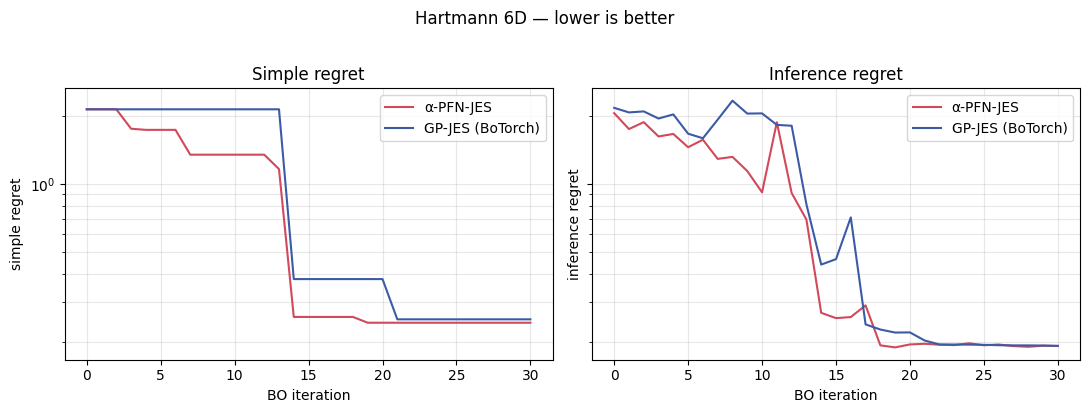


Final simple regret:    α-PFN = 0.2430,  GP-JES = 0.2515
Final inference regret: α-PFN = 0.1917,  GP-JES = 0.1919


In [4]:
import numpy as np
import matplotlib.pyplot as plt

regret_simple_pfn = HARTMANN_OPT - np.asarray(best_obs_pfn)
regret_simple_gp  = HARTMANN_OPT - np.asarray(best_obs_gp)
regret_infer_pfn  = HARTMANN_OPT - np.asarray(best_pred_pfn)
regret_infer_gp   = HARTMANN_OPT - np.asarray(best_pred_gp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
iters = np.arange(num_steps + 1)

ax1.plot(iters, regret_simple_pfn, color="#D1495B", label="α-PFN-JES")
ax1.plot(iters, regret_simple_gp,  color="#3B5BA5", label="GP-JES (BoTorch)")
ax1.set_xlabel("BO iteration"); ax1.set_ylabel("simple regret")
ax1.set_yscale("log"); ax1.set_title("Simple regret")
ax1.legend(loc="upper right"); ax1.grid(alpha=0.3, which="both")

ax2.plot(iters, regret_infer_pfn, color="#D1495B", label="α-PFN-JES")
ax2.plot(iters, regret_infer_gp,  color="#3B5BA5", label="GP-JES (BoTorch)")
ax2.set_xlabel("BO iteration"); ax2.set_ylabel("inference regret")
ax2.set_yscale("log"); ax2.set_title("Inference regret")
ax2.legend(loc="upper right"); ax2.grid(alpha=0.3, which="both")

fig.suptitle("Hartmann 6D — lower is better", y=1.02)
plt.tight_layout(); plt.show()

print(f"\nFinal simple regret:    α-PFN = {regret_simple_pfn[-1]:.4f},  "
      f"GP-JES = {regret_simple_gp[-1]:.4f}")
print(f"Final inference regret: α-PFN = {regret_infer_pfn[-1]:.4f},  "
      f"GP-JES = {regret_infer_gp[-1]:.4f}")


## Next steps

- Try `acquisition="PES"` or `"MES"` in `AlphaPFN.from_pretrained(...)`.
- Plug in your own objective: rescale inputs to `[0, 1]^d` and negate if minimizing (`pfn.fit` standardizes targets internally).
- See the [paper](https://openreview.net/forum?id=7Oonij8oLU) and the `icml2026` branch for full experiments.